# Analyse des résultats et tableau HTML

**Projet** : Gallica Images — Analyse d'illustrations des Métamorphoses d'Ovide  
**Date**   : Avril 2026

Ce notebook charge le CSV brut produit par `collecte_similarite.ipynb`,
calcule des statistiques descriptives et génère un tableau HTML filtrable
**sans colonnes IA** — uniquement les métadonnées Gallica.

**Entrée**  : `resultats/csv/salomon_segmente.csv`  
**Sortie**  : `resultats/similarite/tableau_salomon_segmente.html`

---

## 1. Configuration

In [2]:
import sys
sys.path.insert(0, "..")
from gallica_utils import generer_tableau_html

import pandas as pd
import matplotlib.pyplot as plt
import os

CHEMIN_CSV = "../../resultats/csv/salomon_segmente.csv"
CHEMIN_HTML = "../../resultats/similarite/tableau_salomon_segmente.html"

df = pd.read_csv(CHEMIN_CSV)
print(f"✓ CSV chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")
df.head(3)

✓ CSV chargé : 8300 lignes, 14 colonnes


,salomon_page,salomon_ark,score,titre,auteur,date,corpus,technique,categorie,genre,palette,chromatic_mode,link,result_ark
0,1,bfkfk930z5q,0.9953,[Illustrations de La Métamorphose d'Ovide figu...,Ovide (0043 av. J.-C.-0017). Auteur du texte,1557,NaN,estampe,Ornement typographique,Représentations humaines / Portraits,"blanc, gris, noir",nb,https://openapi.bnf.fr/iiif/image/v3/ark:/1214...,bfkfk930z5q
1,1,bfkfk930z5q,0.9510,Argomento della Galleria Farnese dipinta da An...,"Carracci, Annibale (1560-1609). Peintre",1657,NaN,estampe,Jeu,Représentations humaines / Figures,"blanc, gris, noir",nb,https://openapi.bnf.fr/iiif/image/v3/ark:/1214...,bfkfk84x792
2,1,bfkfk930z5q,0.9507,Les galeries publiques de l'Europe. T1 / par J...,"Armengaud, Jean Germain Désiré (1797-1869). Au...",[1859 TO 1,NaN,estampe,Illustration scientifique / Général,NaN,"noir, blanc, gris",nb,https://openapi.bnf.fr/iiif/image/v3/ark:/1214...,bfkfkb82p56


## 2. Statistiques générales

In [4]:
print("=" * 50)
print("STATISTIQUES GÉNÉRALES")
print("=" * 50)
print(f"  Illustrations Salomon analysées : {df['salomon_page'].nunique()}")
print(f"  Résultats similaires trouvés    : {len(df)}")
print(f"  Score moyen                     : {df['score'].mean():.4f}")
print(f"  Score min / max                 : {df['score'].min():.4f} / {df['score'].max():.4f}")
print()
print("Répartition par technique :")
print(df["technique"].value_counts().to_string())
print()
print("Répartition par genre (top 10) :")
print(df["genre"].value_counts().head(10).to_string())
print()
print("Répartition par mode chromatique :")
print(df["chromatic_mode"].value_counts().to_string())
print()
print("Top 10 titres — occurrences et score moyen :")
print("-" * 55)
top10 = (df.groupby("titre")
           .agg(occurrences=("score", "count"),
                score_moyen= ("score", "mean"),
                score_max=   ("score", "max"))
           .sort_values("occurrences", ascending=False)
           .head(10))
top10["score_moyen"] = top10["score_moyen"].round(4)
top10["score_max"]   = top10["score_max"].round(4)
for titre, row in top10.iterrows():
    print(f"  {row['occurrences']:>4} occ. | moy={row['score_moyen']} | max={row['score_max']} | {str(titre)[:60]}")

STATISTIQUES GÉNÉRALES
  Illustrations Salomon analysées : 164
  Résultats similaires trouvés    : 8300
  Score moyen                     : 0.9383
  Score min / max                 : 0.8961 / 0.9953

Répartition par technique :
technique
estampe         7079
photographie    1186
impression        24
peinture           6
dessin             5

Répartition par genre (top 10) :
genre
Représentations humaines / Scènes              4624
Représentations végétales                      1020
Représentations humaines / Figures              404
Dessins et plans                                404
Représentations scientifiques et techniques     167
Représentations humaines / Portraits            123
Vues d'architecture                              49
Représentations animalières                      33
Motifs décoratifs                                26
Caricatures et dessins humoristiques             16

Répartition par mode chromatique :
chromatic_mode
nb            8063
monochrome     180
couleur 

## 3. Visualisations

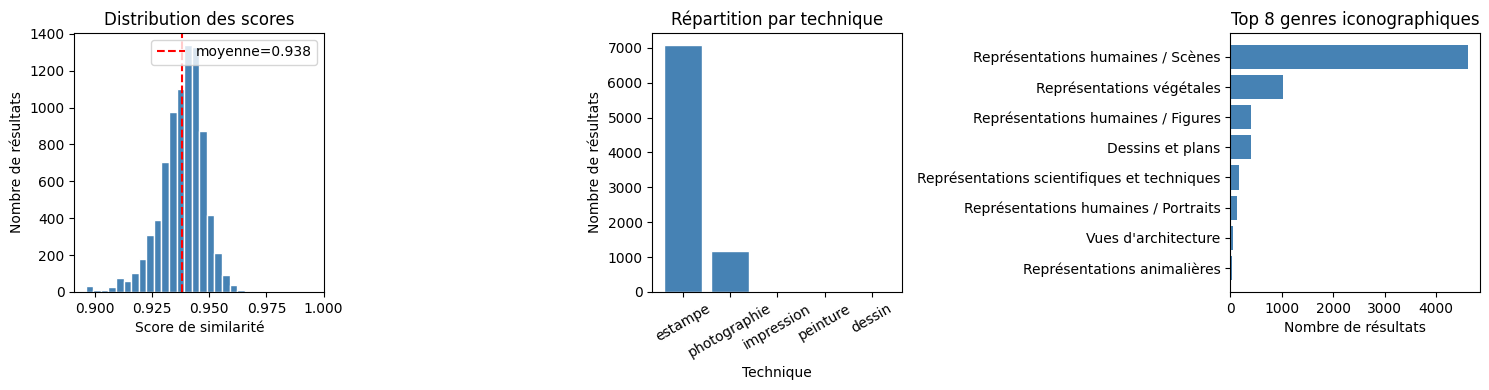

✓ Figure sauvegardée


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution des scores
axes[0].hist(df["score"], bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution des scores")
axes[0].set_xlabel("Score de similarité")
axes[0].set_ylabel("Nombre de résultats")
axes[0].axvline(x=df["score"].mean(), color="red", linestyle="--",
                label=f"moyenne={df['score'].mean():.3f}")
axes[0].legend()

# Répartition par technique
tech_counts = df["technique"].value_counts()
axes[1].bar(tech_counts.index, tech_counts.values, color="steelblue", edgecolor="white")
axes[1].set_title("Répartition par technique")
axes[1].set_xlabel("Technique")
axes[1].set_ylabel("Nombre de résultats")
axes[1].tick_params(axis="x", rotation=30)

# Top 8 genres
genre_counts = df["genre"].value_counts().head(8)
axes[2].barh(genre_counts.index, genre_counts.values, color="steelblue")
axes[2].set_title("Top 8 genres iconographiques")
axes[2].set_xlabel("Nombre de résultats")
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig("../../resultats/similarite/stats_similarite_salomon_segmente.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Figure sauvegardée")

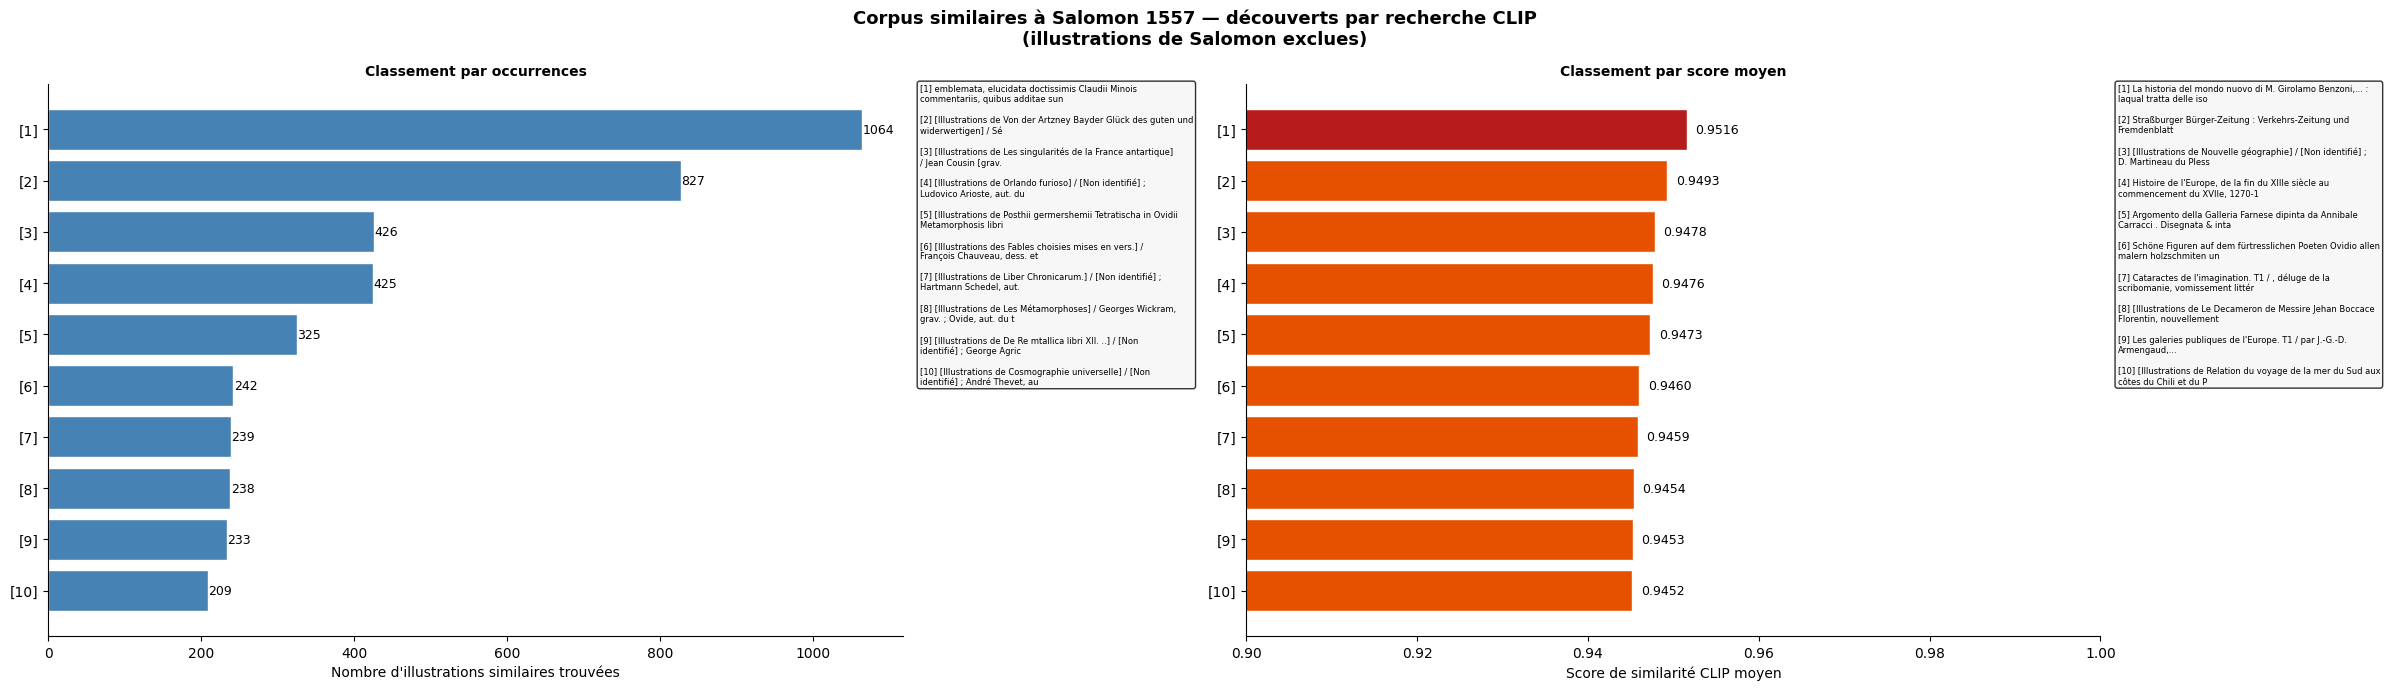

✓ Sauvegardé : corpus_similaires_salomon_segmente.png


In [7]:
import textwrap

# Exclure Salomon lui-même
df_autres = df[~df["titre"].str.contains("Bernard Salomon", na=False)].copy()

# ── Données ──────────────────────────────────────────────────
top_titres     = df_autres["titre"].value_counts().head(10)

score_moyen    = (df_autres.groupby("titre")["score"]
                  .mean()
                  .sort_values(ascending=False)
                  .head(10))

fig, axes = plt.subplots(1, 2, figsize=(24, 7))
fig.suptitle("Corpus similaires à Salomon 1557 — découverts par recherche CLIP\n"
             "(illustrations de Salomon exclues)",
             fontsize=13, fontweight="bold")

# ── Diagramme 1 — Classement par occurrences ─────────────────
ax1      = axes[0]
numeros1 = [f"[{i+1}]" for i in range(len(top_titres))]
bars1    = ax1.barh(numeros1, top_titres.values,
                    color="steelblue", edgecolor="white")
for bar, val in zip(bars1, top_titres.values):
    ax1.text(bar.get_width() + 0.5,
             bar.get_y() + bar.get_height() / 2,
             str(val), va="center", fontsize=9)
ax1.set_xlabel("Nombre d'illustrations similaires trouvées")
ax1.set_title("Classement par occurrences", fontsize=10, fontweight="bold")
ax1.invert_yaxis()
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

legende1 = "\n\n".join(
    [f"[{i+1}] {textwrap.fill(str(t), width=60)}"
     for i, t in enumerate(top_titres.index)]
)
ax1.text(1.02, 1.0, legende1,
         transform=ax1.transAxes,
         fontsize=6, va="top", ha="left",
         bbox=dict(boxstyle="round", facecolor="#f5f5f5", alpha=0.8))

# ── Diagramme 2 — Classement par score moyen ─────────────────
ax2      = axes[1]
numeros2 = [f"[{i+1}]" for i in range(len(score_moyen))]
colors   = ["#b71c1c" if v >= 0.95 else
            "#e65100" if v >= 0.93 else
            "#ff8f00"
            for v in score_moyen.values]
bars2    = ax2.barh(numeros2, score_moyen.values,
                    color=colors, edgecolor="white")
for bar, val in zip(bars2, score_moyen.values):
    ax2.text(bar.get_width() + 0.001,
             bar.get_y() + bar.get_height() / 2,
             f"{val:.4f}", va="center", fontsize=9)
ax2.set_xlabel("Score de similarité CLIP moyen")
ax2.set_title("Classement par score moyen", fontsize=10, fontweight="bold")
ax2.invert_yaxis()
ax2.set_xlim(0.90, 1.0)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

legende2 = "\n\n".join(
    [f"[{i+1}] {textwrap.fill(str(t), width=60)}"
     for i, t in enumerate(score_moyen.index)]
)
ax2.text(1.02, 1.0, legende2,
         transform=ax2.transAxes,
         fontsize=6, va="top", ha="left",
         bbox=dict(boxstyle="round", facecolor="#f5f5f5", alpha=0.8))

plt.tight_layout()
plt.savefig("../../resultats/similarite/corpus_similaires_salomon_segmente.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Sauvegardé : corpus_similaires_salomon_segmente.png")

## 4. Génération du tableau HTML (sans colonnes IA)

In [8]:
# colonnes_ia=[] → tableau sans colonnes IA
# Pour ajouter des colonnes IA, utiliser le notebook modeles/bois_cuivre/application.ipynb
generer_tableau_html(df, CHEMIN_HTML, colonnes_ia=[])

✓ Tableau généré : ../../resultats/similarite/tableau_salomon_segmente.html
✓ URL : http://localhost:8085/tableau_similarite_salomon_segmente.html


gio: http://localhost:8085/tableau_similarite_salomon_segmente.html: Operation not supported
